# Protein Function Prediction (GO) — EDA

This notebook performs domain-specific exploratory data analysis (EDA) for the Gene Ontology (GO) protein function dataset in `data/`.

Goals:
- Understand dataset scale (proteins, labels, taxa).
- Inspect sequence properties (lengths, amino-acid composition, non-standard residues).
- Inspect label properties (multi-label density, long-tail term frequencies, per-aspect distributions).
- Sanity-check joins between sequences, labels, taxonomy, IA weights, and ontology graph.
- Explore GO graph structure and term depths.


In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, Iterator, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

ROOT = Path(".").resolve()
DATA = ROOT / "data"

TRAIN_FASTA = DATA / "Train" / "train_sequences.fasta"
TRAIN_TERMS = DATA / "Train" / "train_terms.tsv"
TRAIN_TAXONOMY = DATA / "Train" / "train_taxonomy.tsv"
GO_OBO = DATA / "Train" / "go-basic.obo"

TESTSUP_FASTA = DATA / "Test" / "testsuperset.fasta"
TESTSUP_TAXA = DATA / "Test" / "testsuperset-taxon-list.tsv"

IA_TSV = DATA / "IA.tsv"
SAMPLE_SUBMISSION = DATA / "sample_submission.tsv"

for p in [TRAIN_FASTA, TRAIN_TERMS, TRAIN_TAXONOMY, GO_OBO, TESTSUP_FASTA, TESTSUP_TAXA, IA_TSV, SAMPLE_SUBMISSION]:
    assert p.exists(), f"Missing file: {p}"

## Load & summarize FASTA files

We compute per-protein sequence length and simple residue statistics without storing sequences in memory.

In [2]:
AA_STD = set(list("ACDEFGHIKLMNPQRSTVWY"))
AA_ALLOW = AA_STD | set(list("BXZJUO*")) | set(list("X"))  # allow common non-standard / ambiguity symbols


def iter_fasta(path: Path) -> Iterator[Tuple[str, str]]:
    header: Optional[str] = None
    seq_parts: List[str] = []
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq_parts)
                header = line[1:]
                seq_parts = []
            else:
                seq_parts.append(line.strip())
        if header is not None:
            yield header, "".join(seq_parts)


def parse_train_accession(header: str) -> str:
    # Example: sp|A0A0C5B5G6|MOTSC_HUMAN ...
    parts = header.split("|")
    if len(parts) >= 3:
        return parts[1]
    return header.split()[0]


def parse_testsuperset_header(header: str) -> Tuple[str, int]:
    # Example: A0A0C5B5G6 9606
    acc, taxon = header.split(maxsplit=1)
    return acc, int(taxon)


def summarize_fasta(
    path: Path,
    kind: str,
    header_parser,
) -> Tuple[pd.DataFrame, Counter]:
    rows = []
    residue_counts: Counter = Counter()

    for header, seq in iter_fasta(path):
        parsed = header_parser(header)
        if isinstance(parsed, tuple):
            accession, taxon = parsed
        else:
            accession, taxon = parsed, None

        seq = seq.upper()
        residue_counts.update(seq)

        nonstd = sum(1 for c in seq if c not in AA_STD)
        unknown = seq.count("X")
        invalid = sum(1 for c in seq if c not in AA_ALLOW)

        rows.append(
            {
                "kind": kind,
                "EntryID": accession,
                "taxon": taxon,
                "length": len(seq),
                "n_X": unknown,
                "n_nonstd": nonstd,
                "n_invalid": invalid,
                "frac_X": unknown / len(seq) if seq else 0.0,
                "frac_nonstd": nonstd / len(seq) if seq else 0.0,
            }
        )

    df = pd.DataFrame(rows)
    return df, residue_counts


train_seq_df, train_res_counts = summarize_fasta(TRAIN_FASTA, kind="train", header_parser=parse_train_accession)
test_seq_df, test_res_counts = summarize_fasta(TESTSUP_FASTA, kind="testsuperset", header_parser=parse_testsuperset_header)

seq_df = pd.concat([train_seq_df, test_seq_df], ignore_index=True)
seq_df.head()

,kind,EntryID,taxon,length,n_X,n_nonstd,n_invalid,frac_X,frac_nonstd
0,train,A0A0C5B5G6,None,16,0,0,0,0.0,0.0
1,train,A0JNW5,None,1464,0,0,0,0.0,0.0
2,train,A0JP26,None,581,0,0,0,0.0,0.0
3,train,A0PK11,None,232,0,0,0,0.0,0.0
4,train,A1A4S6,None,786,0,0,0,0.0,0.0


In [3]:
seq_df.groupby("kind").agg(
    n_proteins=("EntryID", "nunique"),
    total_aa=("length", "sum"),
    mean_len=("length", "mean"),
    median_len=("length", "median"),
    p95_len=("length", lambda s: float(np.percentile(s, 95))),
    max_len=("length", "max"),
    mean_frac_X=("frac_X", "mean"),
    any_invalid=("n_invalid", lambda s: int((s > 0).any())),
).sort_index()

,n_proteins,total_aa,mean_len,median_len,p95_len,max_len,mean_frac_X,any_invalid
kind,,,,,,,,
testsuperset,224309,96280239,429.230388,342.0,1095.0,35213,0.000270,0
train,82404,43327058,525.788287,409.0,1318.0,35213,0.000061,0


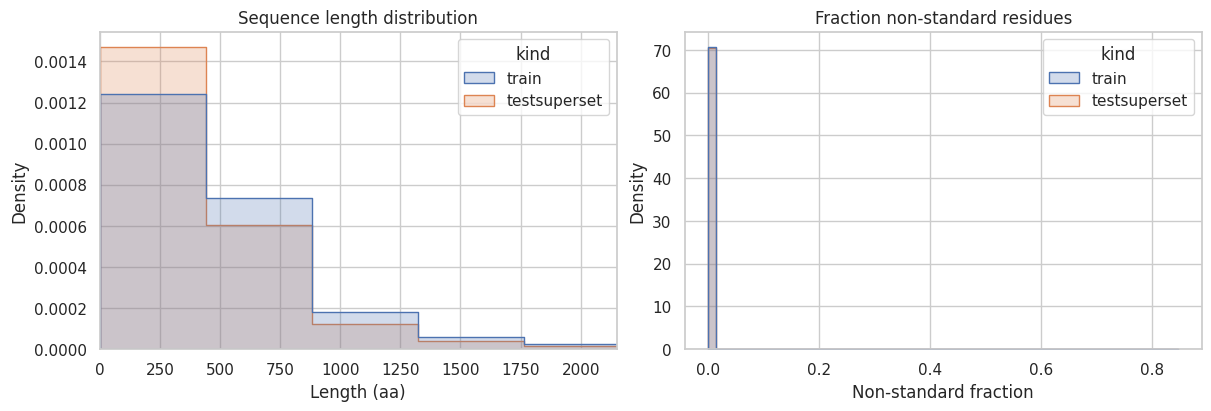

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.histplot(
    data=seq_df,
    x="length",
    hue="kind",
    bins=80,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Sequence length distribution")
axes[0].set_xlabel("Length (aa)")
axes[0].set_xlim(0, np.percentile(seq_df["length"], 99))

sns.histplot(
    data=seq_df,
    x="frac_nonstd",
    hue="kind",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("Fraction non-standard residues")
axes[1].set_xlabel("Non-standard fraction")

plt.show()

In [5]:
def residue_table(res_counts: Counter, top_n: int = 30) -> pd.DataFrame:
    total = sum(res_counts.values())
    df = pd.DataFrame(
        [{"residue": k, "count": v, "freq": v / total} for k, v in res_counts.items()]
    ).sort_values(["count", "residue"], ascending=[False, True])
    return df.head(top_n)


print("Train residue counts (top):")
display(residue_table(train_res_counts, top_n=25))

print("Test superset residue counts (top):")
display(residue_table(test_res_counts, top_n=25))

train_invalid = sorted([r for r in train_res_counts.keys() if r not in AA_ALLOW])
test_invalid = sorted([r for r in test_res_counts.keys() if r not in AA_ALLOW])
print("Invalid residues observed (train):", train_invalid)
print("Invalid residues observed (testsuperset):", test_invalid)

Train residue counts (top):


,residue,count,freq
11,L,4181227,9.650383e-02
14,S,3597577,8.303303e-02
12,A,3045567,7.029249e-02
4,E,2939528,6.784509e-02
5,G,2773867,6.402159e-02
18,V,2695646,6.221623e-02
10,K,2554736,5.896399e-02
9,P,2393286,5.523768e-02
15,T,2360559,5.448233e-02
1,R,2320830,5.356537e-02


Test superset residue counts (top):


,residue,count,freq
11,L,9343579,0.097046
14,S,7662666,0.079587
13,A,6908434,0.071753
4,E,6321162,0.065654
5,G,6271479,0.065138
12,V,6044017,0.062775
10,K,5681589,0.059011
18,T,5250847,0.054537
7,I,5159128,0.053584
1,R,5104470,0.053017


Invalid residues observed (train): []
Invalid residues observed (testsuperset): []


## Load labels, taxonomy, and IA weights

Training labels are multi-label GO annotations. Each row is one (protein, GO term, aspect) assignment.

In [6]:
terms = pd.read_csv(TRAIN_TERMS, sep="\t")
tax = pd.read_csv(TRAIN_TAXONOMY, sep="\t", header=None, names=["EntryID", "taxon"], dtype={"EntryID": str, "taxon": int})
ia = pd.read_csv(IA_TSV, sep="\t", header=None, names=["term", "ia"], dtype={"term": str, "ia": float})

print("terms:")
display(terms.head())
print("taxonomy:")
display(tax.head())
print("IA:")
display(ia.head())

print("\nCounts")
print("terms rows:", len(terms))
print("unique proteins labeled:", terms["EntryID"].nunique())
print("unique terms:", terms["term"].nunique())
print("aspects:")
display(terms["aspect"].value_counts())

terms:


,EntryID,term,aspect
0,Q5W0B1,GO:0000785,C
1,Q5W0B1,GO:0004842,F
2,Q5W0B1,GO:0051865,P
3,Q5W0B1,GO:0006275,P
4,Q5W0B1,GO:0006513,P


taxonomy:


,EntryID,taxon
0,A0A0C5B5G6,9606
1,A0JNW5,9606
2,A0JP26,9606
3,A0PK11,9606
4,A1A4S6,9606


IA:


,term,ia
0,GO:0000001,0.000000
1,GO:0000002,2.849666
2,GO:0000011,0.137504
3,GO:0000012,6.038630
4,GO:0000017,0.514573



Counts
terms rows: 537027
unique proteins labeled: 82404
unique terms: 26125
aspects:


aspect
P    250805
C    157770
F    128452
Name: count, dtype: int64

In [7]:
# Join: sequences ↔ taxonomy ↔ labels
train_meta = (
    train_seq_df[["EntryID", "length", "n_X", "n_nonstd", "n_invalid"]]
    .merge(tax, on="EntryID", how="left", validate="one_to_one")
)

missing_tax = train_meta["taxon"].isna().mean()
print(f"Missing taxon for train proteins: {missing_tax:.3%}")

missing_seq_for_terms = terms[~terms["EntryID"].isin(train_seq_df["EntryID"])]["EntryID"].nunique()
missing_terms_for_seq = train_seq_df[~train_seq_df["EntryID"].isin(terms["EntryID"])]["EntryID"].nunique()
print("Proteins in terms but not in train fasta:", missing_seq_for_terms)
print("Proteins in train fasta but not in terms:", missing_terms_for_seq)

train_meta.describe(include="all")

Missing taxon for train proteins: 0.000%
Proteins in terms but not in train fasta: 0
Proteins in train fasta but not in terms: 0


,EntryID,length,n_X,n_nonstd,n_invalid,taxon
count,82404,82404.000000,82404.000000,82404.000000,82404.0,8.240400e+04
unique,82404,NaN,NaN,NaN,NaN,NaN
top,A0A0C5B5G6,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,525.788287,0.006626,0.008325,0.0,8.345517e+04
std,NaN,521.574869,0.874102,0.878933,0.0,1.801385e+05
min,NaN,3.000000,0.000000,0.000000,0.0,2.870000e+02
25%,NaN,250.000000,0.000000,0.000000,0.0,7.955000e+03
50%,NaN,409.000000,0.000000,0.000000,0.0,9.913000e+03
75%,NaN,630.000000,0.000000,0.000000,0.0,4.468900e+04


## Label EDA (multi-label + long tail)

GO term prediction is extreme multi-label classification: many possible labels, and each protein can have multiple terms.

,n_terms,n_unique_terms,n_aspects
count,82404.000000,82404.000000,82404.000000
mean,6.517002,6.517002,2.163135
std,7.965655,7.965655,0.838340
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,1.000000
50%,4.000000,4.000000,2.000000
75%,8.000000,8.000000,3.000000
max,233.000000,233.000000,3.000000


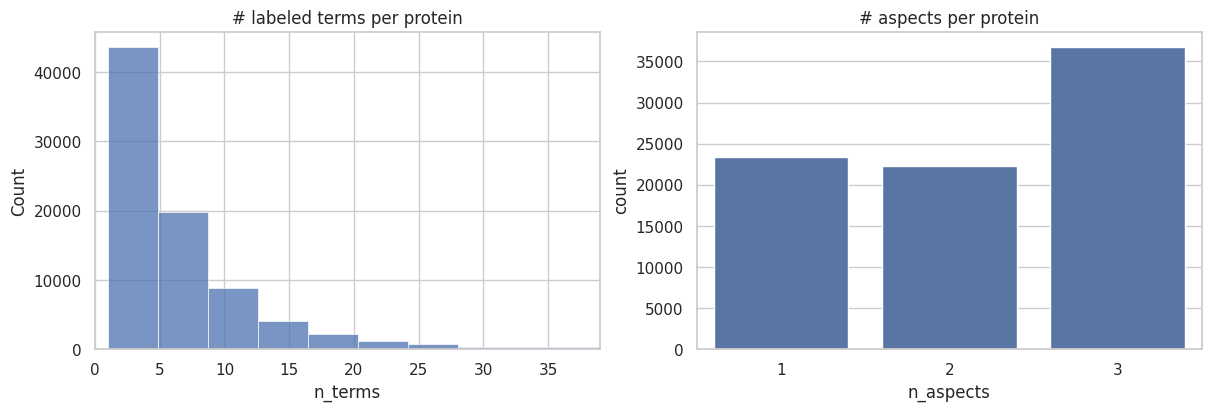

aspect3,BPO,CCO,MFO
count,82404.000000,82404.000000,82404.000000
mean,3.043602,1.914592,1.558808
std,5.607145,2.269205,1.896532
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000
75%,3.000000,3.000000,2.000000
max,188.000000,41.000000,34.000000


In [8]:
aspect_map = {"P": "BPO", "F": "MFO", "C": "CCO"}
terms = terms.copy()
terms["aspect3"] = terms["aspect"].map(aspect_map).fillna(terms["aspect"].astype(str))

per_protein = terms.groupby("EntryID").agg(
    n_terms=("term", "size"),
    n_unique_terms=("term", "nunique"),
    n_aspects=("aspect3", "nunique"),
).reset_index()

per_protein_aspect = (
    terms.groupby(["EntryID", "aspect3"]).size().unstack(fill_value=0).reset_index()
    if len(terms) else pd.DataFrame()
)

display(per_protein.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.histplot(per_protein["n_terms"], bins=60, ax=axes[0])
axes[0].set_title("# labeled terms per protein")
axes[0].set_xlabel("n_terms")
axes[0].set_xlim(0, np.percentile(per_protein["n_terms"], 99))

sns.countplot(x="n_aspects", data=per_protein, ax=axes[1])
axes[1].set_title("# aspects per protein")
axes[1].set_xlabel("n_aspects")

plt.show()

if not per_protein_aspect.empty:
    display(per_protein_aspect.drop(columns=["EntryID"]).describe())

,term,aspect3,n_proteins,n_labels
2709,GO:0005515,MFO,33713,33713
2772,GO:0005634,CCO,13283,13283
2892,GO:0005829,CCO,13040,13040
2931,GO:0005886,CCO,10150,10150
2831,GO:0005737,CCO,9442,9442
2832,GO:0005739,CCO,5807,5807
2781,GO:0005654,CCO,5065,5065
6768,GO:0016020,CCO,3563,3563
12452,GO:0042802,MFO,3547,3547
2735,GO:0005576,CCO,3241,3241


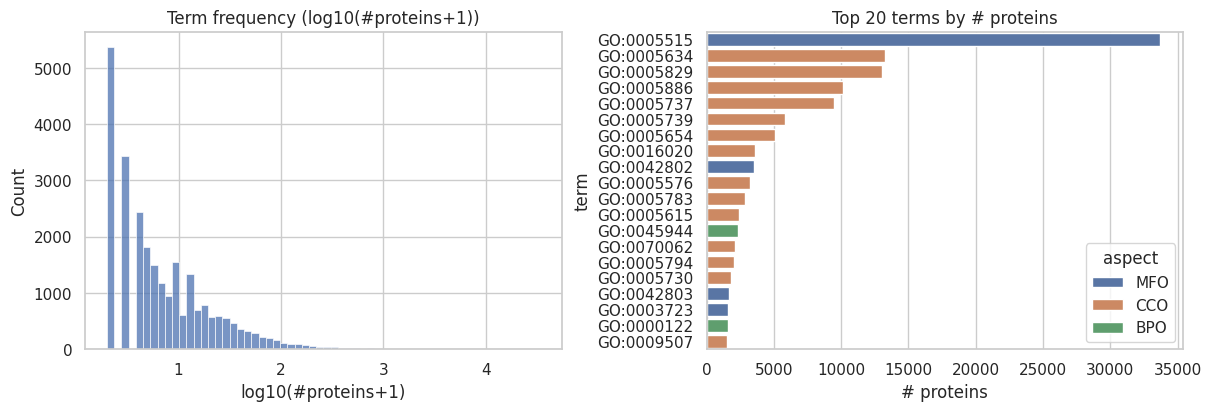

In [9]:
per_term = (
    terms.groupby(["term", "aspect3"]).agg(n_proteins=("EntryID", "nunique"), n_labels=("EntryID", "size")).reset_index()
)

display(per_term.sort_values("n_proteins", ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.histplot(np.log10(per_term["n_proteins"] + 1), bins=60, ax=axes[0])
axes[0].set_title("Term frequency (log10(#proteins+1))")
axes[0].set_xlabel("log10(#proteins+1)")

topk = 20
top_terms = per_term.sort_values("n_proteins", ascending=False).head(topk)
sns.barplot(data=top_terms, y="term", x="n_proteins", hue="aspect3", dodge=False, ax=axes[1])
axes[1].set_title(f"Top {topk} terms by # proteins")
axes[1].set_xlabel("# proteins")
axes[1].set_ylabel("term")
axes[1].legend(title="aspect", loc="lower right")

plt.show()

## Taxonomy EDA

Taxa can act as a distribution shift axis: labels differ across clades, and the test superset provides explicit taxon IDs in the FASTA headers.

,taxon,n_train_proteins,n_testsuperset_proteins
1959,9606,17162.0,20420
2146,10090,12508.0,17240
265,3702,11863.0,16397
7644,559292,5520.0,6733
2158,10116,4909.0,8219
7080,284812,4636.0,5123
5078,83333,3466.0,4531
1237,7227,3201.0,3846
980,6239,2540.0,4493
5077,83332,1530.0,2331


# taxa in train: 1381
# taxa in testsuperset: 8453
# overlapping taxa: 1381


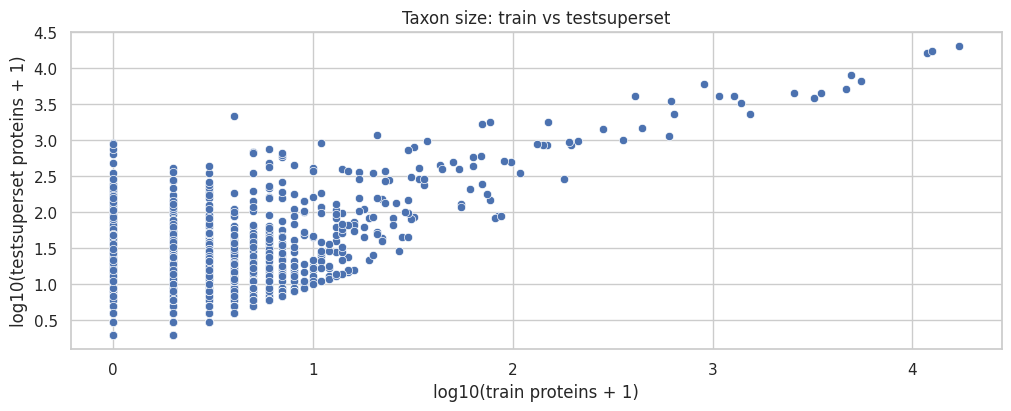

In [10]:
train_tax_counts = tax["taxon"].value_counts().rename_axis("taxon").reset_index(name="n_train_proteins")
test_tax_counts = test_seq_df["taxon"].value_counts().rename_axis("taxon").reset_index(name="n_testsuperset_proteins")
tax_counts = train_tax_counts.merge(test_tax_counts, on="taxon", how="outer").fillna(0)

display(tax_counts.sort_values("n_train_proteins", ascending=False).head(15))

overlap_taxa = set(train_tax_counts["taxon"]).intersection(set(test_tax_counts["taxon"]))
print("# taxa in train:", train_tax_counts.shape[0])
print("# taxa in testsuperset:", test_tax_counts.shape[0])
print("# overlapping taxa:", len(overlap_taxa))

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
sns.scatterplot(
    data=tax_counts,
    x=np.log10(tax_counts["n_train_proteins"] + 1),
    y=np.log10(tax_counts["n_testsuperset_proteins"] + 1),
    ax=ax,
)
ax.set_title("Taxon size: train vs testsuperset")
ax.set_xlabel("log10(train proteins + 1)")
ax.set_ylabel("log10(testsuperset proteins + 1)")
plt.show()

,taxon,n_proteins,n_labels,n_terms,labels_per_protein
471,9606,17162,155400,13412,9.054889
490,10090,12508,109671,12624,8.768068
54,3702,11863,57405,5086,4.838995
1238,559292,5520,37056,4900,6.713043
495,10116,4909,43418,7355,8.844571
1107,284812,4636,20089,2847,4.333261
838,83333,3466,14808,3228,4.272360
334,7227,3201,28050,5003,8.762887
241,6239,2540,14984,2980,5.899213
837,83332,1530,4769,1041,3.116993


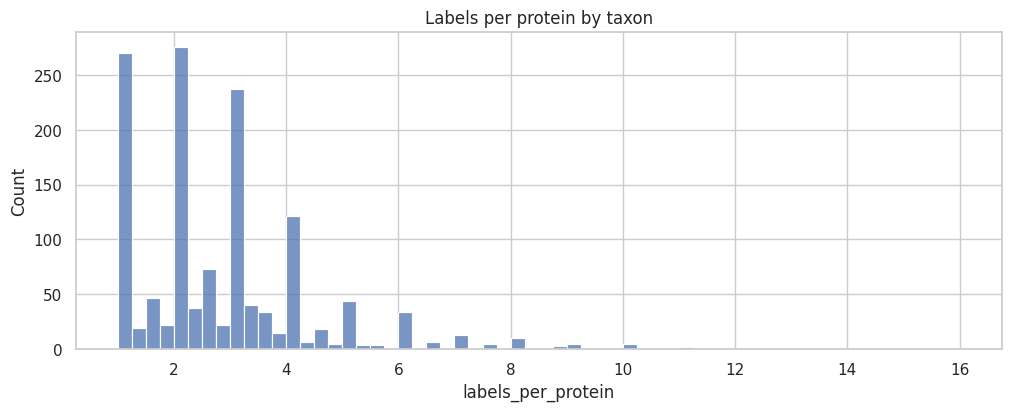

In [11]:
train_terms_tax = terms.merge(tax, on="EntryID", how="left")
label_density_by_tax = (
    train_terms_tax.groupby("taxon").agg(
        n_proteins=("EntryID", "nunique"),
        n_labels=("EntryID", "size"),
        n_terms=("term", "nunique"),
    )
    .reset_index()
)
label_density_by_tax["labels_per_protein"] = label_density_by_tax["n_labels"] / label_density_by_tax["n_proteins"]

display(label_density_by_tax.sort_values("n_proteins", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
sns.histplot(label_density_by_tax["labels_per_protein"], bins=60, ax=ax)
ax.set_title("Labels per protein by taxon")
ax.set_xlabel("labels_per_protein")
plt.show()

## Information Accretion (IA) vs term frequency

IA weights reward more specific terms. A common EDA check is how IA relates to empirical label frequency.

Missing IA for labeled terms: 0


,n_proteins,n_labels,ia
count,26125.000000,26125.000000,26125.000000
mean,20.556057,20.556057,2.310780
std,268.143836,268.143836,2.806843
min,1.000000,1.000000,0.000000
25%,2.000000,2.000000,0.000000
50%,4.000000,4.000000,1.034765
75%,12.000000,12.000000,3.857981
max,33713.000000,33713.000000,14.861014


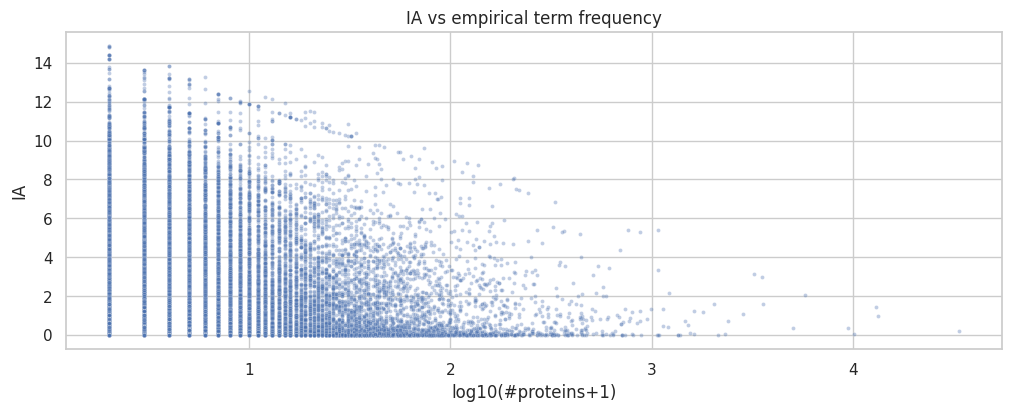

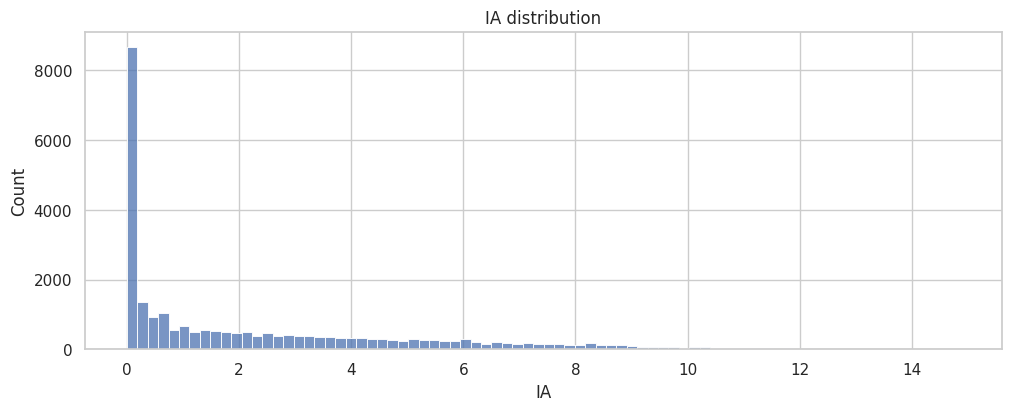

In [12]:
term_freq = terms.groupby("term").agg(n_proteins=("EntryID", "nunique"), n_labels=("EntryID", "size")).reset_index()
term_freq = term_freq.merge(ia, on="term", how="left")

print("Missing IA for labeled terms:", term_freq["ia"].isna().sum())
display(term_freq.describe())

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
sns.scatterplot(
    data=term_freq.sample(min(len(term_freq), 20000), random_state=0),
    x=np.log10(term_freq["n_proteins"] + 1),
    y=term_freq["ia"],
    s=8,
    alpha=0.35,
    ax=ax,
)
ax.set_title("IA vs empirical term frequency")
ax.set_xlabel("log10(#proteins+1)")
ax.set_ylabel("IA")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
sns.histplot(term_freq["ia"].dropna(), bins=80, ax=ax)
ax.set_title("IA distribution")
ax.set_xlabel("IA")
plt.show()

## GO ontology graph EDA (go-basic.obo)

We parse the OBO file to:
- Verify labeled terms are present and not obsolete.
- Measure basic graph size and relationship counts.
- Estimate term depths from the root of each subontology.


In [13]:
@dataclass
class GOTerm:
    term_id: str
    name: Optional[str] = None
    namespace: Optional[str] = None
    is_obsolete: bool = False
    is_a: List[str] = None
    part_of: List[str] = None

    def __post_init__(self):
        if self.is_a is None:
            self.is_a = []
        if self.part_of is None:
            self.part_of = []


def parse_go_basic_obo(path: Path) -> Dict[str, GOTerm]:
    terms: Dict[str, GOTerm] = {}
    current: Optional[GOTerm] = None

    def commit():
        nonlocal current
        if current is not None and current.term_id:
            terms[current.term_id] = current
        current = None

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.rstrip("\n")
            if not line:
                continue
            if line == "[Term]":
                commit()
                current = GOTerm(term_id="")
                continue
            if line.startswith("["):
                # [Typedef] or other block
                commit()
                continue
            if current is None:
                continue

            if line.startswith("id: "):
                current.term_id = line.split("id: ", 1)[1].strip()
            elif line.startswith("name: "):
                current.name = line.split("name: ", 1)[1].strip()
            elif line.startswith("namespace: "):
                current.namespace = line.split("namespace: ", 1)[1].strip()
            elif line.startswith("is_obsolete: "):
                current.is_obsolete = line.split("is_obsolete: ", 1)[1].strip().lower() == "true"
            elif line.startswith("is_a: "):
                parent = line.split("is_a: ", 1)[1].split("!", 1)[0].strip()
                current.is_a.append(parent)
            elif line.startswith("relationship: "):
                rel = line.split("relationship: ", 1)[1].strip()
                if rel.startswith("part_of "):
                    parent = rel.split("part_of ", 1)[1].split("!", 1)[0].strip()
                    current.part_of.append(parent)

    commit()
    return terms


go_terms = parse_go_basic_obo(GO_OBO)
print("# GO terms parsed:", len(go_terms))
print("# obsolete terms:", sum(1 for t in go_terms.values() if t.is_obsolete))

# Build a directed graph parent -> child (so roots are sources)
g_is_a = nx.DiGraph()
g_part = nx.DiGraph()

for term_id, t in go_terms.items():
    g_is_a.add_node(term_id)
    g_part.add_node(term_id)
    for parent in t.is_a:
        g_is_a.add_edge(parent, term_id)
    for parent in t.part_of:
        g_part.add_edge(parent, term_id)

print("is_a edges:", g_is_a.number_of_edges())
print("part_of edges:", g_part.number_of_edges())

# GO terms parsed: 48101
# obsolete terms: 7979
is_a edges: 62410
part_of edges: 6597


In [14]:
subontology_roots = {
    "BPO": "GO:0008150",
    "CCO": "GO:0005575",
    "MFO": "GO:0003674",
}
namespace_to_aspect3 = {
    "biological_process": "BPO",
    "cellular_component": "CCO",
    "molecular_function": "MFO",
}


def compute_depths(graph_parent_to_child: nx.DiGraph, roots: Dict[str, str]) -> pd.DataFrame:
    rows = []
    for aspect3, root in roots.items():
        if root not in graph_parent_to_child:
            continue
        lengths = nx.single_source_shortest_path_length(graph_parent_to_child, root)
        for term_id, depth in lengths.items():
            rows.append({"term": term_id, "aspect3": aspect3, "depth": int(depth)})
    df = pd.DataFrame(rows)
    # If a term is (unexpectedly) reachable from multiple roots, keep the minimum depth.
    if not df.empty:
        df = df.sort_values("depth").drop_duplicates(["term"], keep="first")
    return df


depth_is_a = compute_depths(g_is_a, subontology_roots)
print("Depth coverage (is_a):", depth_is_a["term"].nunique(), "terms")
depth_is_a.head()

Depth coverage (is_a): 40122 terms


,term,aspect3,depth
0,GO:0008150,BPO,0
29991,GO:0003674,MFO,0
25950,GO:0005575,CCO,0
1,GO:0002376,BPO,1
4,GO:0022414,BPO,1


Labeled terms: 26125
Missing labeled terms in go-basic.obo: 0
Obsolete labeled terms: 0
Aspect mismatches (label vs OBO namespace): 0
Missing depth for labeled terms (is_a): 0


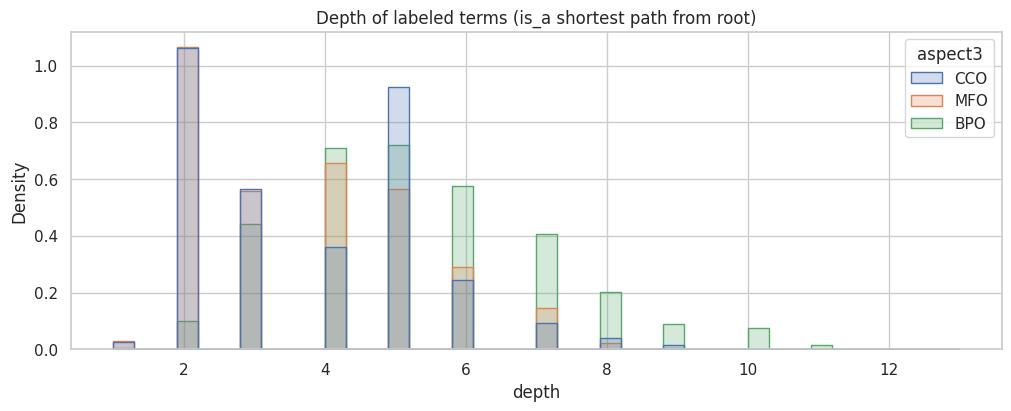

In [15]:
# Coverage: labeled terms in ontology
labeled_terms = set(terms["term"].unique())
obo_terms = set(go_terms.keys())
missing_in_obo = sorted(list(labeled_terms - obo_terms))

print("Labeled terms:", len(labeled_terms))
print("Missing labeled terms in go-basic.obo:", len(missing_in_obo))
if missing_in_obo[:5]:
    print("Examples:", missing_in_obo[:5])

obsolete_labeled = [t for t in labeled_terms if t in go_terms and go_terms[t].is_obsolete]
print("Obsolete labeled terms:", len(obsolete_labeled))
if obsolete_labeled[:5]:
    print("Examples:", obsolete_labeled[:5])

term_namespace = pd.DataFrame(
    [{"term": tid, "namespace": t.namespace, "name": t.name, "is_obsolete": t.is_obsolete} for tid, t in go_terms.items()]
)
term_namespace["aspect3_from_obo"] = term_namespace["namespace"].map(namespace_to_aspect3)

terms_with_obo = terms.merge(term_namespace[["term", "aspect3_from_obo", "is_obsolete"]], on="term", how="left")
mismatch_aspect = terms_with_obo[(~terms_with_obo["aspect3_from_obo"].isna()) & (terms_with_obo["aspect3"] != terms_with_obo["aspect3_from_obo"])]
print("Aspect mismatches (label vs OBO namespace):", len(mismatch_aspect))

terms_depth = terms.merge(depth_is_a[["term", "depth"]], on="term", how="left")
print("Missing depth for labeled terms (is_a):", terms_depth["depth"].isna().sum())

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
sns.histplot(data=terms_depth.dropna(subset=["depth"]), x="depth", hue="aspect3", bins=40, element="step", stat="density", common_norm=False, ax=ax)
ax.set_title("Depth of labeled terms (is_a shortest path from root)")
ax.set_xlabel("depth")
plt.show()

## Submission format sanity check

The provided `sample_submission.tsv` mixes GO term predictions (3 columns) and optional free-text predictions (`Text` rows that can have 4+ columns / wrapped lines). This cell shows a robust way to parse it.

In [16]:
def parse_sample_submission(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 3:
                continue
            entry, label, score = parts[0], parts[1], parts[2]
            text = "\t".join(parts[3:]) if len(parts) > 3 else ""
            rows.append({"EntryID": entry, "label": label, "score": float(score), "text": text})
    return pd.DataFrame(rows)


sub = parse_sample_submission(SAMPLE_SUBMISSION)
display(sub.head(10))
print("Rows:", len(sub))
print("GO rows:", (sub["label"] != "Text").sum())
print("Text rows:", (sub["label"] == "Text").sum())

,EntryID,label,score,text
0,A0A0C5B5G6,GO:0000001,0.123,
1,A0A0C5B5G6,GO:0000002,0.456,
2,A0A0C5B5G6,Text,0.123,Regulates insulin sensitivity and metabolic ho...
3,A0A0C5B5G6,Text,0.456,"Inhibits the folate cycle, thereby reducing de..."
4,A0A0C5B5G6,Text,0.456,and the activation of the metabolic regulator ...
5,A0A1B0GTW7,GO:0000001,0.123,
6,A0A1B0GTW7,GO:0000002,0.456,
7,A0A1B0GTW7,Text,0.123,Putative metalloproteinase that plays a role i...
8,A0JNW5,GO:0000001,0.123,
9,A0JNW5,GO:0000002,0.456,


Rows: 20004
GO rows: 20000
Text rows: 4


## Quick data-quality checklist

- Duplicates in labels (same protein-term repeated)
- Missing taxonomy
- Non-standard/invalid residues
- Overlap between train proteins and test superset (IDs can overlap even if labels differ over time)


In [17]:
dup_labels = terms.duplicated(["EntryID", "term", "aspect3"]).sum()
print("Duplicate (EntryID, term, aspect) rows in train_terms:", int(dup_labels))

print("Train proteins with invalid residues:", int((train_seq_df["n_invalid"] > 0).sum()))
print("Train proteins with any non-standard residues:", int((train_seq_df["n_nonstd"] > 0).sum()))

train_ids = set(train_seq_df["EntryID"])
test_ids = set(test_seq_df["EntryID"])
overlap_ids = train_ids.intersection(test_ids)
print("Train proteins:", len(train_ids))
print("Test superset proteins:", len(test_ids))
print("ID overlap (train ∩ testsuperset):", len(overlap_ids))
if overlap_ids:
    print("Examples:", sorted(list(overlap_ids))[:10])

Duplicate (EntryID, term, aspect) rows in train_terms: 0
Train proteins with invalid residues: 0
Train proteins with any non-standard residues: 200
Train proteins: 82404
Test superset proteins: 224309
ID overlap (train ∩ testsuperset): 82404
Examples: ['A0A023FBW4', 'A0A023FBW7', 'A0A023FDY8', 'A0A023FF81', 'A0A023FFB5', 'A0A023FFD0', 'A0A023FT45', 'A0A023G6B6', 'A0A023G9N9', 'A0A023I7E1']
